In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

cities_label = {"London":"london", 
                #"New York":"newyork", 
                #"Beijing":"beijing",
                #"Hong Kong":"hongkong",
                #"Singapore":"singapore"
                }

from pythermalcomfort.models import pmv_ppd_iso

def get_dynamic_parameters(month, hour):
    # --- 1. 判断是否是睡觉时间 (例如 23:00 - 07:00) ---
    is_sleeping = (hour >= 23) or (hour < 7)

    # --- 2. 设定 Met (代谢率) ---
    if is_sleeping:
        current_met = 0.7  # 睡觉模式：产热极低
    else:
        current_met = 1.2  # 日间模式：正常静坐

    # --- 3. 设定 Clo (服装/被褥) ---
    if is_sleeping:
        # 【关键修正】睡觉必须盖被子！
        # 冬天被子厚一点 (2.5), 夏天薄被子 (1.5)
        if month in [12, 1, 2]:
            current_clo = 2.5  # 厚棉被
        elif month in [6, 7, 8]:
            current_clo = 1.5  # 毯子/薄被
        else:
            current_clo = 2.0  # 普通被子
    else:
        # 白天穿衣服 (之前的逻辑)
        if month in [11, 12, 1, 2, 3, 4]:
            current_clo = 1.0  # 冬装
        elif month in [6, 7, 8]:
            current_clo = 0.5  # 夏装
        else:
            current_clo = 0.75 # 春秋装
            
    return current_clo, current_met


In [2]:
timeslice = ("2012-11", "2013-04")
ds_off = xr.open_dataset("../hac_off/london/default.nc").sel(time=slice(timeslice[0], timeslice[1]))
ds_on = xr.open_dataset("../hac_on/london/default.nc").sel(time=slice(timeslice[0], timeslice[1]))
ds_w = xr.open_dataset("../hac_on_wasteheat/london/default.nc").sel(time=slice(timeslice[0], timeslice[1]))
price_ele =  pd.read_csv('london_avgprice.csv')
price_ele.head()

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


,month,day,hour,ele_price
0,1,1,0.0,10.4195
1,1,1,0.5,13.1355
2,1,1,1.0,14.0525
3,1,1,1.5,8.5540
4,1,1,2.0,9.7160


In [3]:
len_time = ds_off.dims['time']
print("len_time:", len_time)

len_time: 8688


/tmp/ipykernel_3132674/3231231118.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  len_time = ds_off.dims['time']


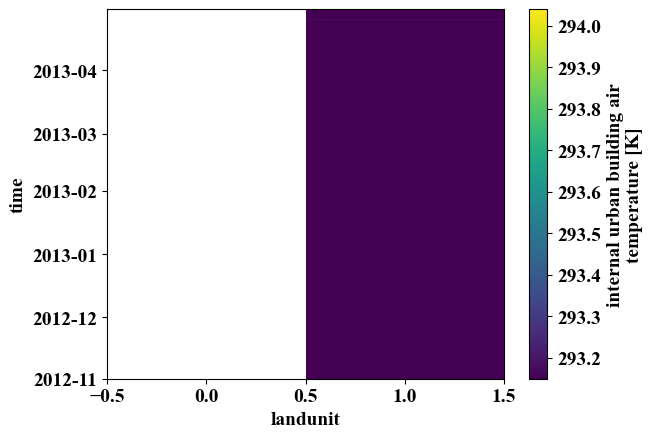

In [4]:
ds_w['TBUILD'].plot(label='with waste heat')

In [8]:
ds_w['URBAN_HEAT'].mean(dim='time')

<xarray.DataArray 'URBAN_HEAT' (landunit: 2)> Size: 8B
array([ 0.      , 23.933949], dtype=float32)
Dimensions without coordinates: landunit

In [5]:
print(ds_w.sel(pft=1)['TSA'].min().values, ds_w.sel(pft=1)['TSA'].max().values)
print(ds_off.sel(landunit=1)['TBUILD'].min().values, ds_off.sel(landunit=1)['TBUILD'].max().values)
print(ds_on.sel(landunit=1)['TBUILD'].min().values, ds_on.sel(landunit=1)['TBUILD'].max().values)
print(price_ele['ele_price'].min(), price_ele['ele_price'].max())

270.8192 297.22418
272.5174 292.6166
293.15 294.07394
3.08 51.0880475


In [6]:
price_ele = price_ele.set_index(['month', 'day', 'hour'])
print(price_ele.max().values[0], price_ele.min().values[0])

51.0880475 3.08


In [7]:
value = price_ele.loc[(1, 1, 0.5)]
value.values[0]

13.1355

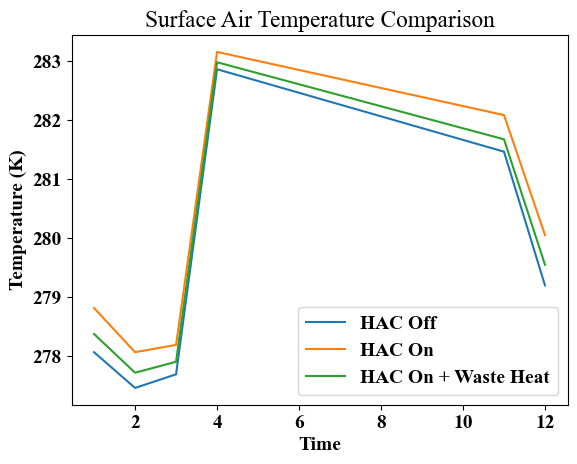

In [8]:
ds_off.sel(pft=1)['TSA'].groupby('time.month').mean().plot(label='HAC Off')
ds_on.sel(pft=1)['TSA'].groupby('time.month').mean().plot(label='HAC On')
ds_w.sel(pft=1)['TSA'].groupby('time.month').mean().plot(label='HAC On + Waste Heat')
plt.legend()
plt.title("Surface Air Temperature Comparison")
plt.xlabel("Time")
plt.ylabel("Temperature (K)")
plt.show()

In [9]:
ds_off['time'] = ds_off['time'].dt.round('min')
ds_off['month'] = ds_off['time'].dt.month
ds_off['hour'] = ds_off['time'].dt.hour + ds_off['time'].dt.minute / 60.0

ds_on['time'] = ds_on['time'].dt.round('min')
ds_on['month'] = ds_on['time'].dt.month
ds_on['hour'] = ds_on['time'].dt.hour + ds_on['time'].dt.minute / 60.0

ds_w['time'] = ds_w['time'].dt.round('min')
ds_w['month'] = ds_w['time'].dt.month
ds_w['hour'] = ds_w['time'].dt.hour + ds_w['time'].dt.minute / 60.0

In [10]:
def cost(P_ac, P_heat, tsa, ele_price):
    COP_cooling = -0.14 * (tsa - 273.15) + 7.31
    COP_heating = 0.07 * (tsa - 273.15) + 3.20
    P_ac = P_ac/COP_cooling*0.5
    P_heat = P_heat/COP_heating*0.5
    r = P_ac + P_heat
    r['time'] = r['time'].dt.round('min')
    r = r.rename("ele").to_dataframe().reset_index()
    r['month'] = r['time'].dt.month
    r['day'] = r['time'].dt.day
    r['hour'] = r['time'].dt.hour + r['time'].dt.minute / 60.0
    r = r.merge(ele_price, left_on=['month', 'day', 'hour'], right_on=['month', 'day', 'hour'])
    r['cost'] = r['ele'] * r['ele_price']
    return r

#def benefit(tbuild):
#    print(tbuild.mean().values)
#    r = 1*(abs(tbuild - 27 - 273.15) + abs(tbuild - 19 - 273.15)-8)
#    return r
def benefit(ta, tr):
    # --- 1. 动态 Clothing (clo) ---
    ta['time'] = ta['time'].dt.round('min')
    month = ta['time'].dt.month.values
    hour = ta['time'].dt.hour.values + ta['time'].dt.minute.values / 60.0
    #clo, met = get_dynamic_parameters(month, hour)
    df = pd.DataFrame({'month':month, 'hour':hour})
    df[['clo', 'met']] = df.apply(lambda row: pd.Series(get_dynamic_parameters(row['month'], row['hour'])), axis=1)
    df['ta'] = ta.values
    df['tr'] = tr.values
    #pmv_result = pmv_ppd_iso(
    #    tdb=ta - 273.15,  # Dry Bulb Temperature in °C
    #    tr=tr - 273.15,  # Mean Radiant Temperature in °C
    #    vr=0.1,  # Relative air speed in m/s
    #    rh=50,  # Relative Humidity in %
    #    met=met,  # Metabolic rate in met
    #    clo=clo,  # Clothing insulation in clo
    #    model="7730-2005",  # Year of the ISO standard
    #    limit_inputs=False  # 【关键修改】强制计算，即使超出范围也不返回 nan
    #)
    df['pmv'] = df.apply(lambda row: pmv_ppd_iso(
        tdb=row['ta'] - 273.15,
        tr=row['tr'] - 273.15,
        vr=0.1,
        rh=50,
        met=row['met'],
        clo=row['clo'],
        model="7730-2005",
        limit_inputs=False
    ).pmv, axis=1)

    def benefit_func(pmv):
        if abs(pmv) <= 0.5:
            return 0
        #elif abs(pmv) > 3:
        #    return -3
        else:
        # 距离死区边界的差值平方
            diff = min(abs(pmv - (-0.5)), abs(pmv - 0.5))
            pmv_penalty = - diff #** 2
            return pmv_penalty
    df['benefit'] = df.apply(lambda row: benefit_func(row['pmv']), axis=1)
    #comfort_reward = -1 * df['pmv'].abs()
    return df


In [11]:
def get_cost_benefit(city):
    ht_roof = 21.3  # in meters
    canyon_hwr = 1.13  # example value, replace with actual canyon height-to-width ratio
    A_floor = ht_roof / canyon_hwr
    A_wall  = ht_roof 
    if city == "London":
        timeslice = ("2012-11", "2013-04")
    else:
        timeslice = ("2021", "2021")

    ds = xr.open_dataset('../hac_on_wasteheat/'+cities_label[city] + "/default.nc").sel(time=slice(*timeslice))
    ds = ds.sel(landunit=1)
    ds = ds.sel(pft=1)
    df_cost = cost(ds['URBAN_AC'], ds['URBAN_HEAT'], ds['TSA'], ele_price=price_ele)
    ds['TBUILD_MRT'] = (ds['TROOF_INNER']*A_floor + ds['TSUNW_INNER']*A_wall + ds['TSHDW_INNER']*A_wall + ds['TFLOOR']*A_floor) / (A_floor + 2*A_wall + A_floor)
    df_benefit = benefit(ds['TBUILD'], ds['TBUILD_MRT'])#.to_dataframe().reset_index().rename(columns={'TBUILD_MRT':'benefit'})
    
    return df_cost, df_benefit

In [12]:
costs = []
benefits = []
costs_max = []
benefits_max = []
costs_min = []
benefits_min = []
for city in cities_label.keys():

    df_cost, df_benefit = get_cost_benefit(city)
    costs.append(df_cost['cost'].mean())
    benefits.append(df_benefit['benefit'].mean())
    costs_max.append(df_cost['cost'].max())
    benefits_max.append(df_benefit['benefit'].max())
    costs_min.append(df_cost['cost'].min())
    benefits_min.append(df_benefit['benefit'].min())
    cost_sum = df_cost['cost'].sum()
    print(f"{city} total cost: {cost_sum}")
    benefit_sum = df_benefit['benefit'].sum()
    print(f"{city} total benefit: {benefit_sum}")
    print(f"{city} norm total cost: {cost_sum/100.0}")
    print("-----")
    print("mean norm reward (w=0.3):", -0.3*cost_sum/100.0 + 0.7*benefit_sum)
    print("mean norm reward (w=0.5):", -0.5*cost_sum/100.0 + 0.5*benefit_sum)
    print("mean norm reward (w=0.7):", -0.7*cost_sum/100.0 + 0.3*benefit_sum)

London total cost: 561915.5115113592
London total benefit: -4892.72
London norm total cost: 5619.155115113593
-----
mean norm reward (w=0.3): -5110.650534534077
mean norm reward (w=0.5): -5255.9375575567965
mean norm reward (w=0.7): -5401.224580579515


In [13]:
df_benefit['benefit'].describe(), (df_cost['cost']/100).describe()

(count    8688.000000
 mean       -0.563158
 std         0.349794
 min        -1.560000
 25%        -0.720000
 50%        -0.480000
 75%        -0.320000
 max         0.000000
 Name: benefit, dtype: float64,
 count    8688.000000
 mean        0.646772
 std         0.316406
 min         0.000000
 25%         0.433691
 50%         0.599182
 75%         0.805279
 max         2.565056
 Name: cost, dtype: float64)

In [14]:
df_benefit

,month,hour,clo,met,ta,tr,pmv,benefit
0,11,0.0,2.0,0.7,293.149994,289.093597,-1.63,-1.13
1,11,0.5,2.0,0.7,293.149994,289.105530,-1.63,-1.13
2,11,1.0,2.0,0.7,293.149994,289.117706,-1.63,-1.13
3,11,1.5,2.0,0.7,293.149994,289.128662,-1.62,-1.12
4,11,2.0,2.0,0.7,293.149994,289.134155,-1.62,-1.12
...,...,...,...,...,...,...,...,...
8683,4,21.5,1.0,1.2,293.149994,290.938049,-0.55,-0.05
8684,4,22.0,1.0,1.2,293.149994,290.898438,-0.56,-0.06
8685,4,22.5,1.0,1.2,293.149994,290.849915,-0.56,-0.06
8686,4,23.0,2.0,0.7,293.149994,290.793854,-1.43,-0.93


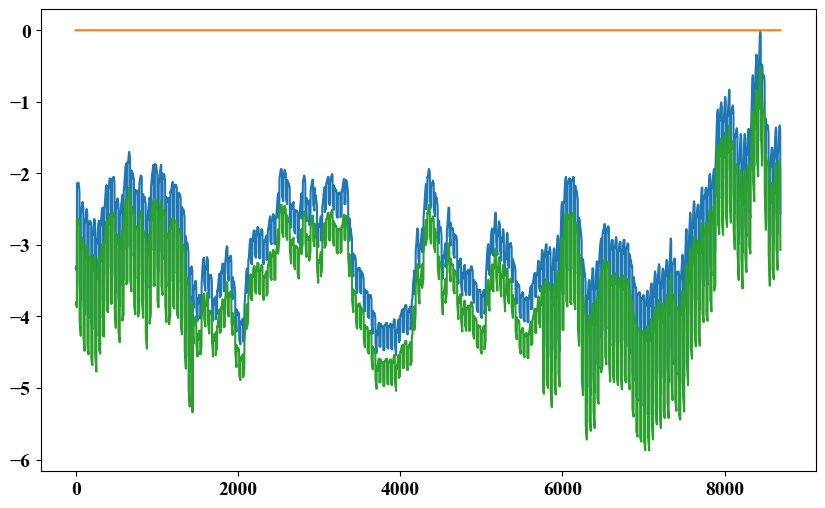

In [20]:
#df_benefit.plot(y='benefit')
cost_benifit1 = df_benefit['benefit']
df_cost1 = df_cost['cost']
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))
cost_benifit1.plot(ax=ax)
(df_cost1/100.0).plot(ax=ax)
df_benefit['pmv'].plot(ax=ax)
#ax.plot((ds_w['TBUILD']-273.15).sel(landunit=1).values)
#ax.set_xlim([8000, 16000])
plt.show()

In [16]:
print("Costs:", costs)
print("Benefits:", benefits)
print("Costs Max:", costs_max)
print("Benefits Max:", benefits_max)    
print("Costs Min:", costs_min)
print("Benefits Min:", benefits_min)
# cost = 50; benefit = 23

Costs: [64.67719975959476]
Benefits: [-0.563158379373849]
Costs Max: [256.50555437031863]
Benefits Max: [0.0]
Costs Min: [0.0]
Benefits Min: [-1.56]


In [17]:
def get_cost_benefit(city):
    
    ht_roof = 21.3  # in meters
    canyon_hwr = 1.13  # example value, replace with actual canyon height-to-width ratio
    A_floor = ht_roof / canyon_hwr
    A_wall  = ht_roof 
    if city == "London":
        timeslice = ("2012-11", "2013-04")
    else:
        timeslice = ("2021", "2021")

    ds = xr.open_dataset('../hac_off/'+cities_label[city] + "/default.nc").sel(time=slice(*timeslice))
    ds = ds.sel(landunit=1)
    ds = ds.sel(pft=1)
    df_cost = cost(ds['URBAN_AC'], ds['URBAN_HEAT'], ds['TSA'], ele_price=price_ele)
    ds['TBUILD_MRT'] = (ds['TROOF_INNER']*A_floor + ds['TSUNW_INNER']*A_wall + ds['TSHDW_INNER']*A_wall + ds['TFLOOR']*A_floor) / (A_floor + 2*A_wall + A_floor)
    df_benefit = benefit(ds['TBUILD'], ds['TBUILD_MRT'])#.to_dataframe().reset_index().rename(columns={'TBUILD_MRT':'benefit'})
    
    return df_cost, df_benefit


costs = []
benefits = []
costs_max = []
benefits_max = []
costs_min = []
benefits_min = []
for city in cities_label.keys():

    #c, b, c_rl, b_rl = get_cost_benefit(city)
    df_cost, df_benefit = get_cost_benefit(city)
    costs.append(df_cost['cost'].mean())
    benefits.append(df_benefit['benefit'].mean())
    costs_max.append(df_cost['cost'].max())
    benefits_max.append(df_benefit['benefit'].max())
    costs_min.append(df_cost['cost'].min())
    benefits_min.append(df_benefit['benefit'].min())
    cost_sum = df_cost['cost'].sum()
    print(f"{city} total cost: {cost_sum}")
    benefit_sum = df_benefit['benefit'].sum()
    print(f"{city} total benefit: {benefit_sum}")
    print(f"{city} norm total cost: {cost_sum/175.0}")
    print("-----")
    print("mean norm reward (w=0.3):", -0.3*cost_sum/175.0 + 0.7*benefit_sum)
    print("mean norm reward (w=0.5):", -0.5*cost_sum/175.0 + 0.5*benefit_sum)
    print("mean norm reward (w=0.7):", -0.7*cost_sum/175.0 + 0.3*benefit_sum)
print("Costs:", costs)
print("Benefits:", benefits)
print("Costs Max:", costs_max)
print("Benefits Max:", benefits_max)    
print("Costs Min:", costs_min)
print("Benefits Min:", benefits_min)
# cost = 50; benefit = 23

London total cost: 0.0
London total benefit: -26438.880000000005
London norm total cost: 0.0
-----
mean norm reward (w=0.3): -18507.216
mean norm reward (w=0.5): -13219.440000000002
mean norm reward (w=0.7): -7931.664000000001
Costs: [0.0]
Benefits: [-3.0431491712707186]
Costs Max: [0.0]
Benefits Max: [-0.020000000000000018]
Costs Min: [0.0]
Benefits Min: [-5.37]


count    8688.000000
mean       -3.043149
std         0.880261
min        -5.370000
25%        -3.640000
50%        -3.085000
75%        -2.420000
max        -0.020000
Name: benefit, dtype: float64

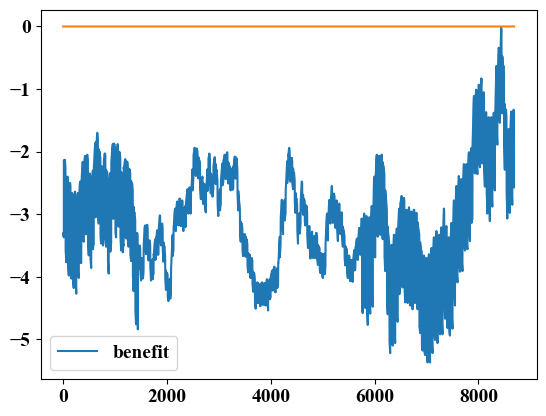

In [18]:
df_benefit.plot( y='benefit')
(df_cost['cost']/175.0).plot()
df_benefit['benefit'].describe()

<Axes: >

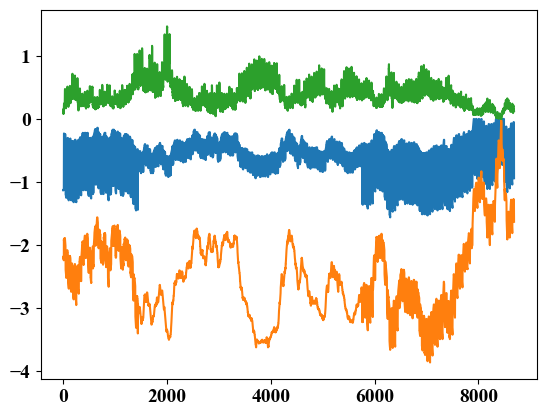

In [19]:
delta_benefit = df_benefit['benefit'] - cost_benifit1

cost_benifit1.plot()
delta_benefit.plot()
(df_cost1/175.0).plot()